# Notebook: Kaggle Digit Recognizer – CNN Classification


# Problem

We are solving the Kaggle “Digit Recognizer” competition, where the task is to classify handwritten digit images (0–9) from pixel values. This uses the famous MNIST dataset.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)


2026-03-05 12:03:44.668341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772712225.006013      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772712225.095360      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772712225.905662      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772712225.905710      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772712225.905713      55 computation_placer.cc:177] computation placer alr

## Load Dataset

In [2]:
train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Preprocess Data

MNIST images are 28×28 grayscale, so we scale pixels to range [0,1] and reshape for CNN input.

In [4]:
# Separate features & labels
X_train = train.drop("label", axis=1).values
y_train = train["label"].values
X_test = test.values

In [5]:
# Normalize pixel values
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# Split into training & validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

## Data Augmentation

To improve generalization and reduce overfitting, we apply small rotations, shifts and zoom

In [6]:
datagen = ImageDataGenerator(
    rotation_range=10,        # rotate images ±10 degrees
    zoom_range=0.1,           # zoom in/out up to 10%
    width_shift_range=0.1,    # shift horizontally
    height_shift_range=0.1    # shift vertically
)

datagen.fit(X_train)

## Create CNN Model

This model uses convolutional layers, batch normalization, and dropout to classify digits.

In [7]:

model = Sequential([

    Input(shape=(28,28,1)),

    Conv2D(32, (3,3), padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),
  
    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    Activation("relu"),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

I0000 00:00:1772712265.329997      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Train Model

We use early stopping and dynamic learning rate reduction to prevent overfitting and speed up convergence.

In [8]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



In [10]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, lr_scheduler]
)



Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1772712269.158464     119 service.cc:152] XLA service 0x78e2ac011030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772712269.158496     119 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772712269.705826     119 cuda_dnn.cc:529] Loaded cuDNN version 91002


 11/591 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3327 - loss: 2.0797

I0000 00:00:1772712273.227535     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


591/591 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8552 - loss: 0.4934 - val_accuracy: 0.9012 - val_loss: 0.3245 - learning_rate: 0.0010
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9678 - loss: 0.1131 - val_accuracy: 0.9776 - val_loss: 0.0688 - learning_rate: 0.0010
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9731 - loss: 0.0883 - val_accuracy: 0.9831 - val_loss: 0.0611 - learning_rate: 0.0010
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9754 - loss: 0.0792 - val_accuracy: 0.9862 - val_loss: 0.0433 - learning_rate: 0.0010
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9813 - loss: 0.0588 - val_accuracy: 0.9905 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9829 - loss: 0.0572 - val_accuracy: 0.9824 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 7/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9837 - loss: 0.0547

## Training & Validation Accuracy Plot

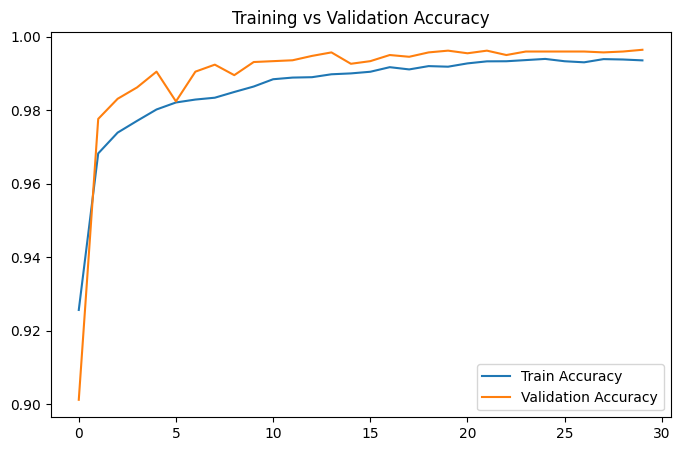

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show();

## Confusion Matrix

In [12]:
val_predictions = model.predict(X_val)
val_predicted_labels = np.argmax(val_predictions, axis=1)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


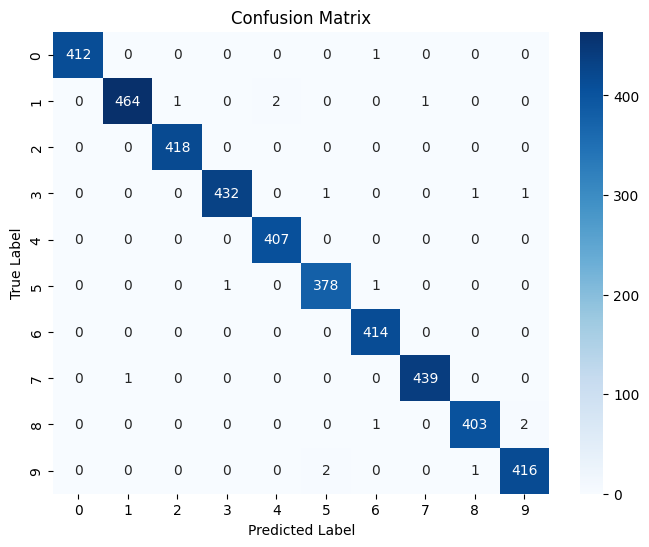

In [13]:
cm = confusion_matrix(y_val, val_predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Error Analysis

In [14]:
# Predictions already computed
# val_predictions
# val_predicted_labels

# 1️⃣ Define true labels
Y_true = y_val
Y_pred_classes = val_predicted_labels
Y_pred = val_predictions

# 2️⃣ Find errors
errors = (Y_pred_classes != Y_true)

# 3️⃣ Extract error samples
Y_pred_errors = Y_pred[errors]
Y_pred_classes_errors = Y_pred_classes[errors]
Y_true_errors = Y_true[errors]
X_val_errors = X_val[errors]

# 4️⃣ Confidence of wrong prediction
pred_prob_errors = np.max(Y_pred_errors, axis=1)

# 5️⃣ Probability of the true class
true_prob_errors = Y_pred_errors[np.arange(len(Y_pred_errors)), Y_true_errors]

# 6️⃣ Confidence gap
delta_errors = pred_prob_errors - true_prob_errors

# 7️⃣ Sort by most overconfident mistakes
sorted_errors = np.argsort(delta_errors)

# 8️⃣ Take top 6 most confident wrong predictions
top_errors = sorted_errors[-6:]

In [15]:
def display_errors(errors_index, images, pred_labels, true_labels):
    n = 0
    nrows = 2
    ncols = 3

    fig, ax = plt.subplots(nrows, ncols, figsize=(10,6))

    for row in range(nrows):
        for col in range(ncols):
            error = errors_index[n]
            ax[row, col].imshow(images[error].reshape(28,28), cmap='gray')
            ax[row, col].set_title(
                f"Pred: {pred_labels[error]} | True: {true_labels[error]}"
            )
            ax[row, col].axis('off')
            n += 1

    plt.tight_layout()
    plt.show()

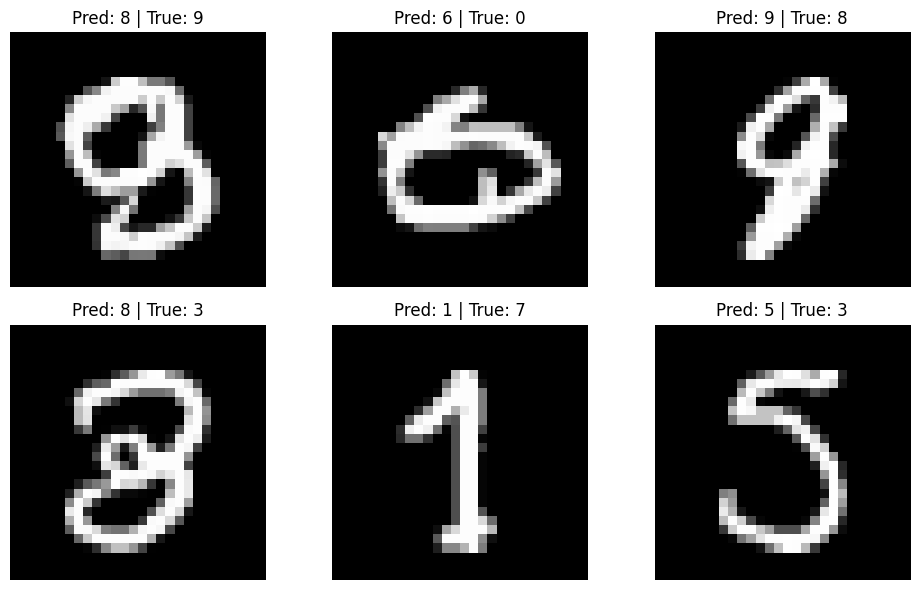

In [16]:
display_errors(top_errors, X_val_errors, Y_pred_classes_errors, Y_true_errors)

In [17]:
conf_matrix_df = pd.DataFrame(cm)

# Zero out diagonal (correct predictions)
for i in range(10):
    conf_matrix_df.iloc[i, i] = 0

print(conf_matrix_df.stack().sort_values(ascending=False).head(10))

1  4    2
8  9    2
9  5    2
1  7    1
3  5    1
5  6    1
7  1    1
9  8    1
3  8    1
   9    1
dtype: int64


## Predict Test Set & Save Submission

In [18]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [19]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predicted_labels)+1),
    "Label": predicted_labels
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv!")



Saved submission.csv!
